# Özellik Mühendisliği

## Genel Bakış

Bu notebook, ham EPİAŞ elektrik tüketim verisini (`full_data.csv`) alarak LightGBM modelinin eğitimi için zengin bir özellik matrisi oluşturur.

**Adımlar:**
1. Veri yükleme ve datetime dönüşümü
2. Lag özellikleri (24h, 48h, 168h, 336h)
3. Rolling istatistikler (ortalama, std, maks)
4. CDD / HDD (sıcaklık sütunu kontrolü)
5. Takvim özellikleri + döngüsel encoding + Türkiye tatil bayrağı
6. NaN satırlarını düşür
7. Özellik raporu ve korelasyon grafiği
8. İşlenmiş veriyi kaydet

In [1]:
import zipfile
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import holidays

warnings.filterwarnings("ignore")

# Tekrarlanabilirlik için seed
np.random.seed(42)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


---
## 1. Veri Yükleme ve Datetime Dönüşümü

Ham veri, `data/raw/full_data.csv.zip` arşivinden okunur. `time` sütununun formatı `DD:MM:YYYY:HH:MM` şeklindedir; `pandas.to_datetime` ile parse edilerek `DatetimeIndex`'e dönüştürülür ve sütunun artık gerekmeyen string versiyonu düşürülür.

In [2]:
ZIP_PATH  = "../data/raw/full_data.csv.zip"
CSV_NAME  = "full_data.csv"

with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open(CSV_NAME) as f:
        df_raw = pd.read_csv(f)

print(f"Ham veri boyutu : {df_raw.shape}")
print(f"Sütunlar        : {df_raw.columns.tolist()}")
print(f"\nİlk 3 satır:")
df_raw.head(3)

Ham veri boyutu : (52584, 22)
Sütunlar        : ['time', 'consumption_MWh', 'total_generation_MWh', 'natural_gas', 'hydro_dam', 'lignite', 'hydro_river', 'coal_imported', 'wind', 'solar', 'fuel_oil', 'geothermal', 'asphaltite_coal', 'hard_coal', 'biomass', 'naphtha', 'LNG', 'international', 'waste_heat', 'TRY/MWh', 'USD/MWh', 'EUR/MWh']

İlk 3 satır:


,time,consumption_MWh,total_generation_MWh,natural_gas,hydro_dam,lignite,hydro_river,coal_imported,wind,solar,...,asphaltite_coal,hard_coal,biomass,naphtha,LNG,international,waste_heat,TRY/MWh,USD/MWh,EUR/MWh
0,01:01:2018:00:00,27412.81,27412.81,6926.78,4820.40,5226.32,1900.32,5314.05,1179.51,0.0,...,278.20,189.5,210.96,0.0,0.0,297.0,92.08,207.60,55.04,45.97
1,01:01:2018:01:00,26324.39,26324.39,6603.44,3644.32,5277.19,1877.83,5715.61,1148.46,0.0,...,284.82,205.5,211.67,0.0,0.0,287.0,91.14,205.34,54.44,45.47
2,01:01:2018:02:00,24635.32,24635.32,6040.77,2711.00,5325.47,1708.49,5701.37,1216.38,0.0,...,278.20,201.5,209.89,0.0,0.0,169.0,91.06,164.94,43.73,36.53


In [3]:
# time sütununu datetime'a çevir ve DatetimeIndex yap
df_raw["datetime"] = pd.to_datetime(df_raw["time"], format="%d:%m:%Y:%H:%M")
df = df_raw.drop(columns=["time"]).set_index("datetime").sort_index()

# Tüketim sütunu tespiti
TARGET_COL = "consumption_MWh"
assert TARGET_COL in df.columns, f"'{TARGET_COL}' sütunu bulunamadı!"

print(f"DatetimeIndex: {df.index[0]} → {df.index[-1]}")
print(f"Toplam satır  : {len(df):,}")
print(f"Hedef sütun   : {TARGET_COL}")
print(f"NaN sayısı    : {df.isnull().sum().sum()}")
df[[TARGET_COL]].describe().round(2)

DatetimeIndex: 2018-01-01 00:00:00 → 2023-12-31 23:00:00
Toplam satır  : 52,584
Hedef sütun   : consumption_MWh
NaN sayısı    : 0


,consumption_MWh
count,52584.00
mean,35166.89
std,5743.83
min,15333.30
25%,30814.88
50%,35063.73
75%,39281.60
max,55575.02


---
## 2. Lag Özellikleri

Elektrik tüketimi güçlü bir otokorelasyon gösterir. Modelin geçmiş değerlere erişmesi için dört temel lag oluşturulur:

| Özellik | Gecikme | Motivasyon |
|---|---|---|
| `lag_24` | 24 saat | Dünün aynı saati |
| `lag_48` | 48 saat | İki gün öncesinin aynı saati |
| `lag_168` | 168 saat | Tam bir hafta öncesi (aynı gün + aynı saat) |
| `lag_336` | 336 saat | İki hafta öncesi |

> **Not:** Lag değerleri, seri başındaki satırlarda `NaN` üretir. Bu satırlar 6. adımda düşürülecektir.

In [4]:
LAG_HOURS = [24, 48, 168, 336]

for lag in LAG_HOURS:
    df[f"lag_{lag}"] = df[TARGET_COL].shift(lag)

print("Lag özellikleri oluşturuldu:")
for lag in LAG_HOURS:
    col = f"lag_{lag}"
    nan_count = df[col].isna().sum()
    print(f"  {col:12s} → ilk {nan_count} satır NaN")

Lag özellikleri oluşturuldu:
  lag_24       → ilk 24 satır NaN
  lag_48       → ilk 48 satır NaN
  lag_168      → ilk 168 satır NaN
  lag_336      → ilk 336 satır NaN


---
## 3. Rolling İstatistikler

Pencereli istatistikler, kısa ve uzun vadeli tüketim trendini yakalar. `min_periods=1` yerine varsayılan (tam pencere) kullanılır; NaN'lar 6. adımda toplu olarak temizlenir.

| Özellik | Pencere | Açıklama |
|---|---|---|
| `rolling_mean_24` | 24 saat | Son 24 saatin ortalaması (günlük ortalama) |
| `rolling_std_24` | 24 saat | Son 24 saatin standart sapması (volatilite) |
| `rolling_mean_168` | 168 saat | Son 7 günün ortalaması (haftalık trend) |
| `rolling_max_72` | 72 saat | Son 72 saatin maksimumu (zirve tüketim) |

In [5]:
s = df[TARGET_COL]

df["rolling_mean_24"]  = s.shift(1).rolling(24).mean()
df["rolling_std_24"]   = s.shift(1).rolling(24).std()
df["rolling_mean_168"] = s.shift(1).rolling(168).mean()
df["rolling_max_72"]   = s.shift(1).rolling(72).max()

rolling_cols = ["rolling_mean_24", "rolling_std_24", "rolling_mean_168", "rolling_max_72"]
print("Rolling istatistikler oluşturuldu:")
for col in rolling_cols:
    print(f"  {col:20s} → NaN sayısı: {df[col].isna().sum()}")

Rolling istatistikler oluşturuldu:
  rolling_mean_24      → NaN sayısı: 24
  rolling_std_24       → NaN sayısı: 24
  rolling_mean_168     → NaN sayısı: 168
  rolling_max_72       → NaN sayısı: 72


---
## 4. CDD / HDD (Sıcaklık Sütunu Kontrolü)

Soğutma Derece Günü (CDD) ve Isıtma Derece Günü (HDD), elektrik tüketiminin iklimsel bileşenini modeller. Baz sıcaklık **18°C**'dir:

```
CDD = max(0, T - 18)
HDD = max(0, 18 - T)
```

Veri setinde sıcaklık sütunu **mevcut değilse** bu adım atlanır ve bir uyarı gösterilir. Sıcaklık verisi Open-Meteo API'den çekilerek gelecekteki bir notebook'ta eklenebilir.

In [6]:
BASE_TEMP = 18.0

# Olası sıcaklık sütun adlarını ara
temp_candidates = [c for c in df.columns if "temp" in c.lower() or "sicaklik" in c.lower()]

if temp_candidates:
    TEMP_COL = temp_candidates[0]
    print(f"Sıcaklık sütunu bulundu: '{TEMP_COL}'")
    df["cdd"] = (df[TEMP_COL] - BASE_TEMP).clip(lower=0)
    df["hdd"] = (BASE_TEMP - df[TEMP_COL]).clip(lower=0)
    print("CDD ve HDD özellikleri oluşturuldu.")
else:
    print("⚠️  Sıcaklık sütunu bulunamadı → CDD/HDD adımı atlandı.")
    print("   İpucu: Open-Meteo API ile sıcaklık verisi ekleyerek bu özellikler hesaplanabilir.")

⚠️  Sıcaklık sütunu bulunamadı → CDD/HDD adımı atlandı.
   İpucu: Open-Meteo API ile sıcaklık verisi ekleyerek bu özellikler hesaplanabilir.


---
## 5. Takvim Özellikleri

### 5a. Temel Takvim Değişkenleri
Saatlik granülaritede en güçlü örüntüler saat, haftanın günü ve aydır.

### 5b. İkili Bayraklar
- `is_weekend`: Cumartesi (5) veya Pazar (6) günleri 1, diğerleri 0
- `is_holiday`: `holidays` kütüphanesi ile Türkiye resmî tatil günleri

### 5c. Döngüsel (Sinüzoidal) Encoding
Saat, gün ve ay değişkenleri sıralıdır ama döngüseldir (23→0, Aralık→Ocak). Lineer değerler modeli yanıltır; sin/cos çifti döngüyü doğru temsil eder:

```
hour_sin = sin(2π × hour / 24)
hour_cos = cos(2π × hour / 24)
```

In [7]:
# --- 5a. Temel takvim değişkenleri ---
df["hour"]        = df.index.hour
df["day_of_week"] = df.index.dayofweek          # 0=Pazartesi … 6=Pazar
df["month"]       = df.index.month
df["day_of_year"] = df.index.dayofyear
df["year"]        = df.index.year

# --- 5b. İkili bayraklar ---
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Türkiye resmî tatil günleri (2018–2023 yıllarını kapsayacak şekilde)
years = df.index.year.unique().tolist()
tr_holidays = holidays.Turkey(years=years)
holiday_dates = set(tr_holidays.keys())
df["is_holiday"] = df.index.normalize().map(lambda d: int(d.date() in holiday_dates))

print(f"is_weekend → toplam hafta sonu saati : {df['is_weekend'].sum():,}")
print(f"is_holiday → toplam tatil günü saati  : {df['is_holiday'].sum():,}")
print(f"  Tespit edilen tatil günleri ({len(tr_holidays)} adet):")
for d, name in sorted(tr_holidays.items())[:6]:
    print(f"    {d}  {name}")

is_weekend → toplam hafta sonu saati : 15,024
is_holiday → toplam tatil günü saati  : 1,992
  Tespit edilen tatil günleri (83 adet):
    2018-01-01  New Year's Day
    2018-04-23  National Sovereignty and Children's Day
    2018-05-01  Labour and Solidarity Day
    2018-05-19  Commemoration of Atatürk, Youth and Sports Day
    2018-06-15  Eid al-Fitr
    2018-06-16  Eid al-Fitr


In [8]:
# --- 5c. Döngüsel encoding ---
df["hour_sin"]        = np.sin(2 * np.pi * df["hour"]        / 24)
df["hour_cos"]        = np.cos(2 * np.pi * df["hour"]        / 24)

df["month_sin"]       = np.sin(2 * np.pi * df["month"]       / 12)
df["month_cos"]       = np.cos(2 * np.pi * df["month"]       / 12)

df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

calendar_cols = [
    "hour", "day_of_week", "month", "day_of_year", "year",
    "is_weekend", "is_holiday",
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "day_of_week_sin", "day_of_week_cos",
]
print("Takvim özellikleri oluşturuldu:")
for c in calendar_cols:
    print(f"  {c}")

Takvim özellikleri oluşturuldu:
  hour
  day_of_week
  month
  day_of_year
  year
  is_weekend
  is_holiday
  hour_sin
  hour_cos
  month_sin
  month_cos
  day_of_week_sin
  day_of_week_cos


---
## 6. NaN Satırlarını Düşür

Lag ve rolling özellikler seri başında `NaN` üretir. En büyük gecikme `lag_336` (336 saat = 14 gün) olduğundan, rolling `rolling_mean_168` ile birlikte en fazla **336 + 168 = 504 saate** kadar NaN oluşabilir. `dropna()` bu satırları veri setinden çıkarır.

In [9]:
before = len(df)
df.dropna(inplace=True)
after = len(df)

dropped = before - after
print(f"Düşürülen satır sayısı : {dropped:,}")
print(f"Kalan satır sayısı     : {after:,}  ({after/before*100:.2f}% korundu)")
print(f"Yeni zaman aralığı     : {df.index[0]} → {df.index[-1]}")
print(f"Kalan NaN sayısı       : {df.isnull().sum().sum()}")

Düşürülen satır sayısı : 336
Kalan satır sayısı     : 52,248  (99.36% korundu)
Yeni zaman aralığı     : 2018-01-15 00:00:00 → 2023-12-31 23:00:00
Kalan NaN sayısı       : 0


---
## 7. Özellik Raporu ve Korelasyon Analizi

Oluşturulan tüm özellikler listelenir ve her birinin hedef değişken (`consumption_MWh`) ile Pearson korelasyonu hesaplanır. Yüksek mutlak korelasyon, özelliğin modele güçlü sinyal taşıdığını gösterir.

In [10]:
# Mühendislik yapılan özellik listesi (hedef + ham kaynak sütunlar hariç)
raw_source_cols = [
    "total_generation_MWh", "natural_gas", "hydro_dam", "lignite",
    "hydro_river", "coal_imported", "wind", "solar", "fuel_oil",
    "geothermal", "asphaltite_coal", "hard_coal", "biomass", "naphtha",
    "LNG", "international", "waste_heat", "TRY/MWh", "USD/MWh", "EUR/MWh"
]

feature_cols = [c for c in df.columns if c != TARGET_COL and c not in raw_source_cols]

print(f"{'='*55}")
print(f"  Özellik Özeti")
print(f"{'='*55}")
print(f"  Oluşturulan özellik sayısı : {len(feature_cols)}")
print(f"  Toplam satır sayısı        : {len(df):,}")
print(f"  Zaman aralığı              : {df.index[0].date()} → {df.index[-1].date()}")
print(f"{'='*55}")
print(f"\n  Özellik listesi:")
for i, col in enumerate(feature_cols, 1):
    print(f"    {i:2d}. {col}")

  Özellik Özeti
  Oluşturulan özellik sayısı : 21
  Toplam satır sayısı        : 52,248
  Zaman aralığı              : 2018-01-15 → 2023-12-31

  Özellik listesi:
     1. lag_24
     2. lag_48
     3. lag_168
     4. lag_336
     5. rolling_mean_24
     6. rolling_std_24
     7. rolling_mean_168
     8. rolling_max_72
     9. hour
    10. day_of_week
    11. month
    12. day_of_year
    13. year
    14. is_weekend
    15. is_holiday
    16. hour_sin
    17. hour_cos
    18. month_sin
    19. month_cos
    20. day_of_week_sin
    21. day_of_week_cos


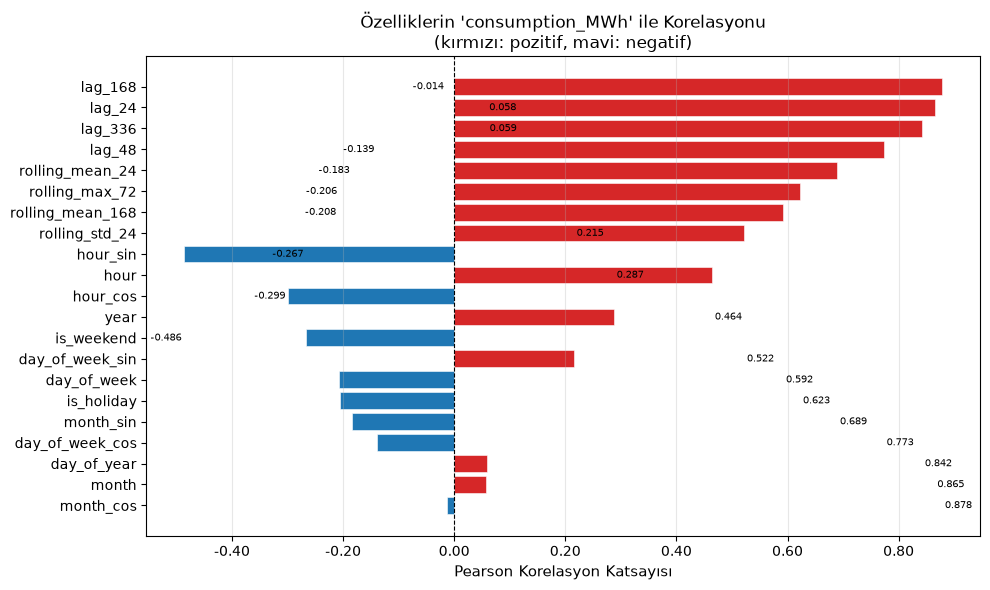

Grafik kaydedildi: outputs/figures/feature_correlations.png


In [11]:
# Pearson korelasyonları hesapla ve sırala
corr = df[feature_cols].corrwith(df[TARGET_COL]).sort_values(key=abs, ascending=False)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#d62728" if v >= 0 else "#1f77b4" for v in corr.values]
bars = ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], edgecolor="white", linewidth=0.4)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson Korelasyon Katsayısı", fontsize=11)
ax.set_title(f"Özelliklerin '{TARGET_COL}' ile Korelasyonu\n(kırmızı: pozitif, mavi: negatif)", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="x", alpha=0.3)

# Değer etiketleri
for bar, val in zip(bars[::-1], corr.values[::-1]):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("../outputs/figures/feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: outputs/figures/feature_correlations.png")

In [12]:
# Korelasyon tablosu
corr_df = corr.reset_index()
corr_df.columns = ["Özellik", "Korelasyon"]
corr_df["Mutlak Korelasyon"] = corr_df["Korelasyon"].abs().round(4)
corr_df["Korelasyon"]        = corr_df["Korelasyon"].round(4)
corr_df.index = range(1, len(corr_df) + 1)
corr_df

,Özellik,Korelasyon,Mutlak Korelasyon
1,lag_168,0.8783,0.8783
2,lag_24,0.8646,0.8646
3,lag_336,0.8422,0.8422
4,lag_48,0.7733,0.7733
5,rolling_mean_24,0.6893,0.6893
6,rolling_max_72,0.6227,0.6227
7,rolling_mean_168,0.5922,0.5922
8,rolling_std_24,0.5219,0.5219
9,hour_sin,-0.4859,0.4859
10,hour,0.4641,0.4641


---
## 8. İşlenmiş Veriyi Kaydet

Tüm özellikler ve hedef değişken `data/processed/featured_data.csv` dosyasına kaydedilir. Bu dosya `03_modeling.ipynb` tarafından doğrudan okunacaktır.

> **Sütun düzeni:** önce hedef (`consumption_MWh`), ardından mühendislik özellikleri, sonra kaynak sütunlar.

In [13]:
import os

OUT_PATH = "../data/processed/featured_data.csv"
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

# Sütun sırası: hedef → mühendislik özellikleri → kaynak sütunlar
ordered_cols = [TARGET_COL] + feature_cols + [c for c in raw_source_cols if c in df.columns]
df[ordered_cols].to_csv(OUT_PATH)

size_mb = os.path.getsize(OUT_PATH) / 1024**2
print(f"Kaydedildi : {OUT_PATH}")
print(f"Dosya boyutu: {size_mb:.1f} MB")
print(f"Satır sayısı: {len(df):,}")
print(f"Sütun sayısı: {len(ordered_cols)}")
print(f"\nİlk 3 satır (yalnızca mühendislik sütunları):")
df[feature_cols].head(3)

Kaydedildi : ../data/processed/featured_data.csv
Dosya boyutu: 19.4 MB
Satır sayısı: 52,248
Sütun sayısı: 42

İlk 3 satır (yalnızca mühendislik sütunları):


,lag_24,lag_48,lag_168,lag_336,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_max_72,hour,day_of_week,...,day_of_year,year,is_weekend,is_holiday,hour_sin,hour_cos,month_sin,month_cos,day_of_week_sin,day_of_week_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-15 00:00:00,32078.92,33173.42,30009.04,27412.81,31691.409167,3020.162384,35056.282083,41432.46,0,0,...,15,2018,0,0,0.000000,1.000000,0.5,0.866025,0.0,1.0
2018-01-15 01:00:00,30126.00,31491.98,28448.55,26324.39,31645.869583,3022.304521,35062.097143,41432.46,1,0,...,15,2018,0,0,0.258819,0.965926,0.5,0.866025,0.0,1.0
2018-01-15 02:00:00,28790.96,30062.70,27289.37,24635.32,31614.173750,3042.855847,35067.553988,41432.46,2,0,...,15,2018,0,0,0.500000,0.866025,0.5,0.866025,0.0,1.0


---
## Özet

| Grup | Özellikler |
|---|---|
| **Lag** | `lag_24`, `lag_48`, `lag_168`, `lag_336` |
| **Rolling** | `rolling_mean_24`, `rolling_std_24`, `rolling_mean_168`, `rolling_max_72` |
| **CDD/HDD** | Sıcaklık sütunu olmadığı için atlandı |
| **Takvim (temel)** | `hour`, `day_of_week`, `month`, `day_of_year`, `year` |
| **Takvim (bayrak)** | `is_weekend`, `is_holiday` |
| **Döngüsel** | `hour_sin/cos`, `month_sin/cos`, `day_of_week_sin/cos` |

**Sonraki adım:** `03_modeling.ipynb` → LightGBM modeli eğitimi, zaman serisi çapraz doğrulama, MAPE / RMSE değerlendirmesi.